In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

import joblib

In [2]:
df = pd.read_csv(
    "../data/preprocessed_dataset.csv"
)

df.head()

,Asset_Type,Total_Maintenance_Cost,Condition_Score,Failure_Impact_Score,Failure_History_Count,Operating_Hours,Environmental_Stress_Index,System_Importance_Score,Failure_Probability,Budget_Constraint_Flag,RUL,Days_Since_Maintenance
0,3,45406.15,9.22,4,5,81703,0.99,0.64,0.52,1,5.90,1617
1,2,33701.25,9.58,19,0,42445,0.73,0.59,0.83,1,10.26,2398
2,0,28241.81,3.94,91,6,48636,0.36,0.90,0.82,0,3.08,1557
3,2,5993.98,4.19,45,6,74927,0.70,0.65,0.95,0,0.73,1474
4,2,22629.25,5.55,43,9,79194,0.73,0.35,0.69,0,1.89,2076


In [3]:
X = df[[

    'Asset_Type',

    'Total_Maintenance_Cost',

    'Condition_Score',

    'Failure_Impact_Score',

    'Failure_History_Count',

    'Operating_Hours',

    'Environmental_Stress_Index',

    'System_Importance_Score',

    'Budget_Constraint_Flag',

    'Days_Since_Maintenance',

    'Failure_Probability'
]]

y = df['RUL']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42
)

print(X_train.shape)

print(X_test.shape)

(800, 11)
(200, 11)


In [5]:
categorical_features = [
    'Asset_Type'
]

numeric_features = [

    'Total_Maintenance_Cost',

    'Condition_Score',

    'Failure_Impact_Score',

    'Failure_History_Count',

    'Operating_Hours',

    'Environmental_Stress_Index',

    'System_Importance_Score',

    'Budget_Constraint_Flag',

    'Days_Since_Maintenance',

    'Failure_Probability'
]

In [6]:
preprocess = ColumnTransformer(

    transformers=[

        (
            'cat',

            OneHotEncoder(
                handle_unknown='ignore'
            ),

            categorical_features
        ),

        (
            'num',

            StandardScaler(),

            numeric_features
        )
    ]
)

In [7]:
rf_pipeline = Pipeline(steps=[

    (
        'preprocess',

        preprocess
    ),

    (
        'model',

        RandomForestRegressor(
            random_state=42
        )
    )
])

In [8]:
rf_params = {

    'model__n_estimators': [100, 200],

    'model__max_depth': [10, 15],

    'model__min_samples_split': [2, 5],

    'model__min_samples_leaf': [1, 2]
}

In [9]:
rf_grid = GridSearchCV(

    estimator=rf_pipeline,

    param_grid=rf_params,

    cv=5,

    scoring='r2',

    n_jobs=-1,

    verbose=1
)

rf_grid.fit(
    X_train,
    y_train
)

best_rf_model = rf_grid.best_estimator_

print("===== BEST RANDOM FOREST PARAMETERS =====")

print(rf_grid.best_params_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
===== BEST RANDOM FOREST PARAMETERS =====
{'model__max_depth': 15, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}


In [10]:

rf_predictions = best_rf_model.predict(
    X_test
)

rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_mse = mean_squared_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(rf_mse)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("\n===== TUNED RANDOM FOREST RESULTS =====")

print(f"MAE  : {rf_mae:.4f}")

print(f"RMSE : {rf_rmse:.4f}")

print(f"R²   : {rf_r2:.4f}")


===== TUNED RANDOM FOREST RESULTS =====
MAE  : 0.1679
RMSE : 0.2319
R²   : 0.9959


In [11]:

joblib.dump(

    best_rf_model,

    "../models/tuned_random_forest.pkl"
)

print("Tuned Random Forest Saved")

Tuned Random Forest Saved


In [12]:
xgb_pipeline = Pipeline(steps=[

    (
        'preprocess',

        preprocess
    ),

    (
        'model',

        XGBRegressor(
            random_state=42
        )
    )
])

In [13]:
xgb_params = {

    'model__n_estimators': [100, 200],

    'model__learning_rate': [0.01, 0.05, 0.1],

    'model__max_depth': [4, 6, 8],

    'model__subsample': [0.8, 1.0]
}

In [14]:
xgb_grid = GridSearchCV(

    estimator=xgb_pipeline,

    param_grid=xgb_params,

    cv=5,

    scoring='r2',

    n_jobs=-1,

    verbose=1
)

xgb_grid.fit(
    X_train,
    y_train
)

best_xgb_model = xgb_grid.best_estimator_

print("===== BEST XGBOOST PARAMETERS =====")

print(xgb_grid.best_params_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
===== BEST XGBOOST PARAMETERS =====
{'model__learning_rate': 0.1, 'model__max_depth': 4, 'model__n_estimators': 200, 'model__subsample': 0.8}


In [15]:
xgb_predictions = best_xgb_model.predict(
    X_test
)

xgb_mae = mean_absolute_error(
    y_test,
    xgb_predictions
)

xgb_mse = mean_squared_error(
    y_test,
    xgb_predictions
)

xgb_rmse = np.sqrt(xgb_mse)

xgb_r2 = r2_score(
    y_test,
    xgb_predictions
)

print("\n===== TUNED XGBOOST RESULTS =====")

print(f"MAE  : {xgb_mae:.4f}")

print(f"RMSE : {xgb_rmse:.4f}")

print(f"R²   : {xgb_r2:.4f}")


===== TUNED XGBOOST RESULTS =====
MAE  : 0.1633
RMSE : 0.2148
R²   : 0.9965


In [16]:
joblib.dump(

    best_xgb_model,

    "../models/tuned_xgboost.pkl"
)

print("Tuned XGBoost Saved")

Tuned XGBoost Saved


In [17]:
results = pd.DataFrame({

    'Model': [

        'Tuned Random Forest',

        'Tuned XGBoost'
    ],

    'MAE': [

        rf_mae,

        xgb_mae
    ],

    'RMSE': [

        rf_rmse,

        xgb_rmse
    ],

    'R² Score': [

        rf_r2,

        xgb_r2
    ]
})

results

,Model,MAE,RMSE,R² Score
0,Tuned Random Forest,0.167947,0.231947,0.995946
1,Tuned XGBoost,0.163327,0.214789,0.996524


In [18]:
feature_names = (

    best_xgb_model.named_steps['preprocess']

    .get_feature_names_out()
)

importance = pd.DataFrame({

    'Feature': feature_names,

    'Importance':

    best_xgb_model.named_steps['model']

    .feature_importances_
})

importance = importance.sort_values(

    by='Importance',

    ascending=False
)

importance.head(10)

,Feature,Importance
6,num__Condition_Score,0.548767
9,num__Operating_Hours,0.445247
11,num__System_Importance_Score,0.000640
14,num__Failure_Probability,0.000635
5,num__Total_Maintenance_Cost,0.000586
10,num__Environmental_Stress_Index,0.000525
8,num__Failure_History_Count,0.000513
12,num__Budget_Constraint_Flag,0.000490
13,num__Days_Since_Maintenance,0.000488
7,num__Failure_Impact_Score,0.000482


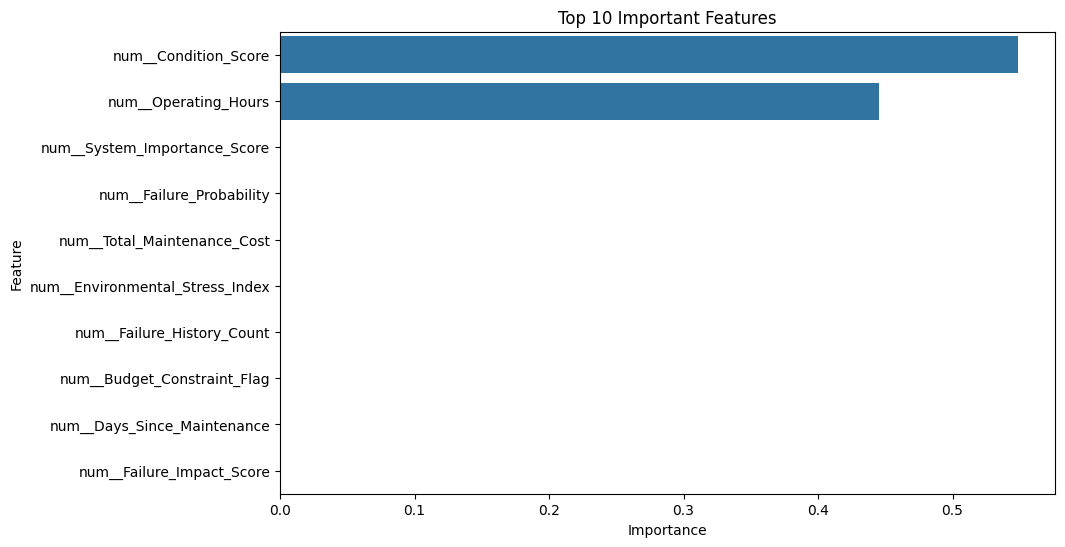

In [19]:
plt.figure(figsize=(10,6))

sns.barplot(

    x='Importance',

    y='Feature',

    data=importance.head(10)
)

plt.title(
    "Top 10 Important Features"
)

plt.show()

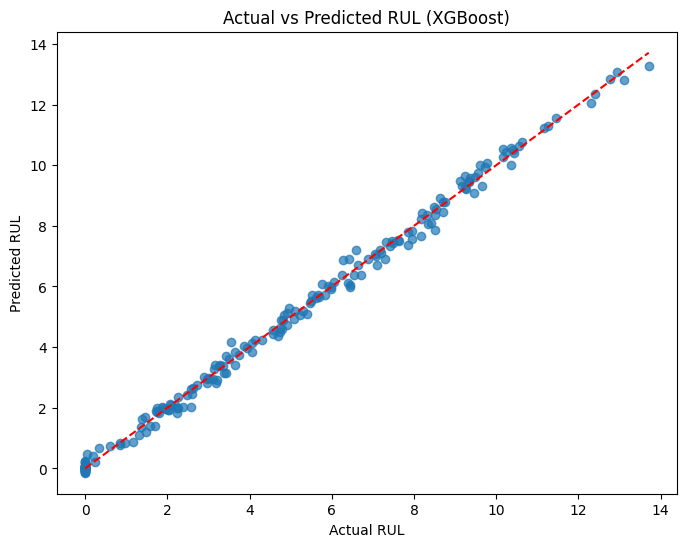

In [20]:
plt.figure(figsize=(8,6))

plt.scatter(

    y_test,

    xgb_predictions,

    alpha=0.7
)

plt.plot(

    [y_test.min(), y_test.max()],

    [y_test.min(), y_test.max()],

    'r--'
)

plt.xlabel("Actual RUL")

plt.ylabel("Predicted RUL")

plt.title(
    "Actual vs Predicted RUL (XGBoost)"
)

plt.show()